In [1]:
##DenseNet121##

In [2]:
import os
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split


In [4]:
df = pd.read_csv("final_dataset.csv")
train_df, val_df = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)

datagen = ImageDataGenerator(rescale=1./255)

train_gen = datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=(224, 224),
    class_mode="categorical",
    batch_size=32
)

val_gen = datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=(224, 224),
    class_mode="categorical",
    batch_size=32,
    shuffle=False
)

num_classes = len(train_gen.class_indices)


Found 42241 validated image filenames belonging to 7 classes.
Found 4694 validated image filenames belonging to 7 classes.


In [5]:
base_model = DenseNet121(include_top=False, input_shape=(224, 224, 3), weights='imagenet', pooling='avg')
base_model.trainable = False  # Freeze base initially

model = models.Sequential([
    base_model,
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,305,799 (27.87 MB)

 Trainable params: 266,247 (1.02 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ModelCheckpoint("densenet_best.h5", save_best_only=True)
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks,
    verbose=1
)


c:\Users\devgo\OneDrive\Desktop\project\.venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8372 - loss: 0.4931

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 2370s 2s/step - accuracy: 0.8373 - loss: 0.4930 - val_accuracy: 0.9265 - val_loss: 0.2153
Epoch 2/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 967ms/step - accuracy: 0.9168 - loss: 0.2403

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 1356s 1s/step - accuracy: 0.9168 - loss: 0.2403 - val_accuracy: 0.9335 - val_loss: 0.1936
Epoch 3/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 540ms/step - accuracy: 0.9278 - loss: 0.2086

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 936s 709ms/step - accuracy: 0.9278 - loss: 0.2086 - val_accuracy: 0.9376 - val_loss: 0.1824
Epoch 4/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9343 - loss: 0.1891

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 2812s 2s/step - accuracy: 0.9343 - loss: 0.1891 - val_accuracy: 0.9393 - val_loss: 0.1728
Epoch 5/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 3507s 3s/step - accuracy: 0.9374 - loss: 0.1768 - val_accuracy: 0.9410 - val_loss: 0.1753
Epoch 6/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.9430 - loss: 0.1634

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 1617s 1s/step - accuracy: 0.9430 - loss: 0.1634 - val_accuracy: 0.9421 - val_loss: 0.1690
Epoch 7/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 1911s 1s/step - accuracy: 0.9435 - loss: 0.1602 - val_accuracy: 0.9433 - val_loss: 0.1773
Epoch 8/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 1609s 1s/step - accuracy: 0.9475 - loss: 0.1485 - val_accuracy: 0.9425 - val_loss: 0.1706
Epoch 9/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 1612s 1s/step - accuracy: 0.9482 - loss: 0.1431 - val_accuracy: 0.9410 - val_loss: 0.1816
Epoch 10/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 1594s 1s/step - accuracy: 0.9502 - loss: 0.1401 - val_accuracy: 0.9384 - val_loss: 0.1892
Epoch 11/15
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 1607s 1s/step - accuracy: 0.9547 - loss: 0.1273 - val_accuracy: 0.9423 - val_loss: 0.1862


In [7]:
# Unfreeze base model
base_model.trainable = True

# Recompile with low learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 6050s 4s/step - accuracy: 0.7874 - loss: 0.7343 - val_accuracy: 0.9335 - val_loss: 0.1980
Epoch 2/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9294 - loss: 0.1955

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 4733s 4s/step - accuracy: 0.9294 - loss: 0.1955 - val_accuracy: 0.9423 - val_loss: 0.1604
Epoch 3/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 3312s 3s/step - accuracy: 0.9445 - loss: 0.1528 - val_accuracy: 0.9337 - val_loss: 0.2070
Epoch 4/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 3306s 3s/step - accuracy: 0.9544 - loss: 0.1224 - val_accuracy: 0.9205 - val_loss: 0.2643
Epoch 5/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9627 - loss: 0.1025

1321/1321 ━━━━━━━━━━━━━━━━━━━━ 4874s 4s/step - accuracy: 0.9627 - loss: 0.1025 - val_accuracy: 0.9493 - val_loss: 0.1471
Epoch 6/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 6908s 5s/step - accuracy: 0.9699 - loss: 0.0838 - val_accuracy: 0.9510 - val_loss: 0.1517
Epoch 7/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 7704s 6s/step - accuracy: 0.9782 - loss: 0.0618 - val_accuracy: 0.9472 - val_loss: 0.1663
Epoch 8/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 8729s 7s/step - accuracy: 0.9807 - loss: 0.0505 - val_accuracy: 0.9493 - val_loss: 0.1909
Epoch 9/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 7031s 5s/step - accuracy: 0.9874 - loss: 0.0379 - val_accuracy: 0.9433 - val_loss: 0.1952
Epoch 10/20
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 7084s 5s/step - accuracy: 0.9902 - loss: 0.0278 - val_accuracy: 0.9169 - val_loss: 0.3432


In [8]:
loss, acc = model.evaluate(val_gen)
print(f"✅ DenseNet121 Final Validation Accuracy: {acc:.4f}")


147/147 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step - accuracy: 0.9476 - loss: 0.1508
✅ DenseNet121 Final Validation Accuracy: 0.9493


In [10]:
model.save("densenet121_skin_classifier.h5")

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get ground truth and predictions
y_true = val_gen.classes  # Actual labels
y_pred_probs = model.predict(val_gen)
y_pred = np.argmax(y_pred_probs, axis=1)  # Predicted class indices

# Get class names
class_labels = list(val_gen.class_indices.keys())

# Print classification report (includes precision, recall, F1-score)
report = classification_report(y_true, y_pred, target_names=class_labels, digits=4)
print("📋 Classification Report:\n")
print(report)


147/147 ━━━━━━━━━━━━━━━━━━━━ 222s 1s/step
📋 Classification Report:

              precision    recall  f1-score   support

       AKIEC     0.9675    0.9776    0.9725       670
         BCC     0.9507    0.9791    0.9647       670
         BKL     0.9278    0.9001    0.9138       671
          DF     0.9925    0.9896    0.9910       671
         MEL     0.9716    0.8659    0.9157       671
          NV     0.8512    0.9388    0.8928       670
        VASC     0.9955    0.9940    0.9948       671

    accuracy                         0.9493      4694
   macro avg     0.9510    0.9493    0.9493      4694
weighted avg     0.9510    0.9493    0.9493      4694



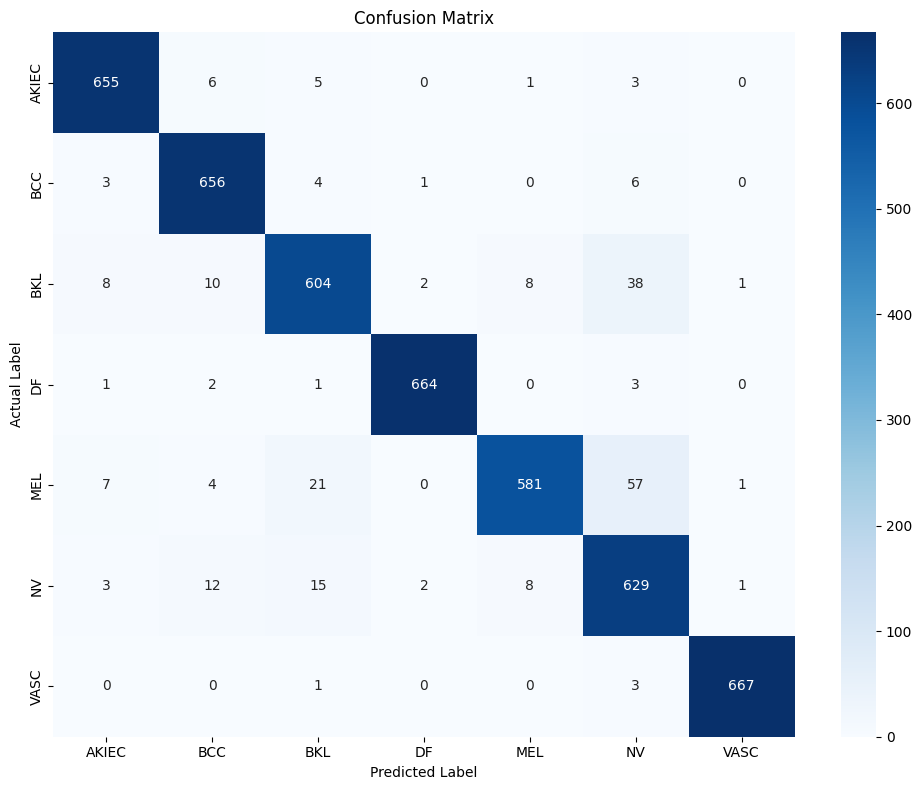

In [12]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot it
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()


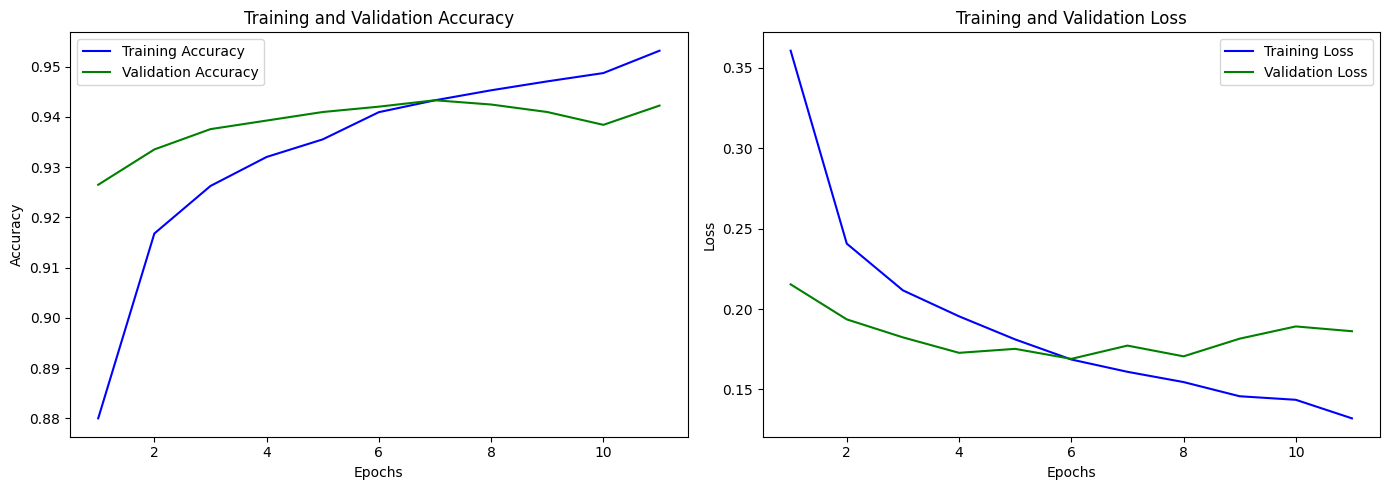

In [13]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'g-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'g-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Call it after training
plot_training_history(history)


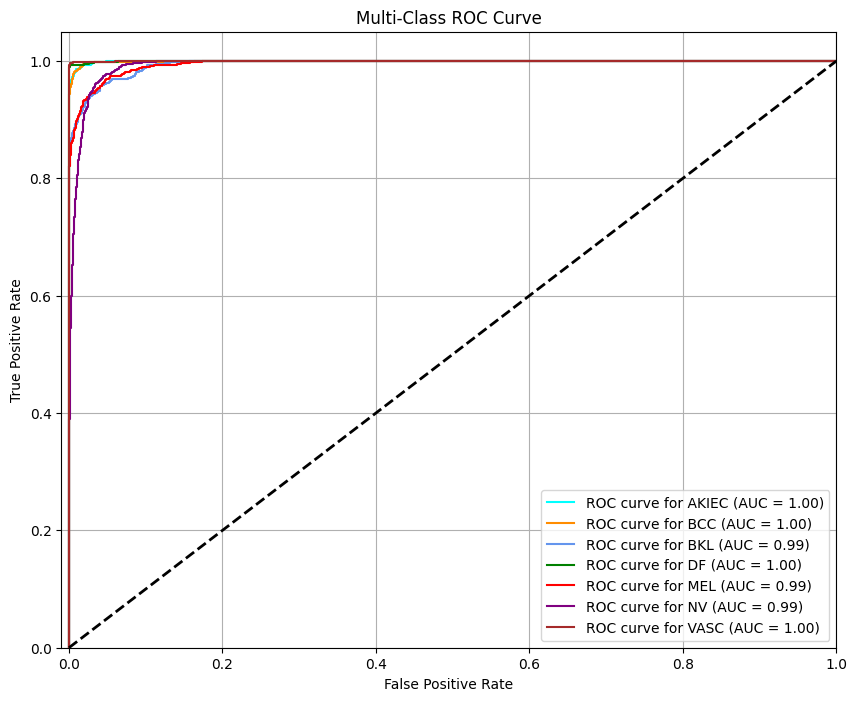

In [14]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from itertools import cycle

def plot_multiclass_roc_auc(y_true, y_pred_probs, class_labels):
    n_classes = len(class_labels)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot all ROC curves
    plt.figure(figsize=(10, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])

    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color,
                 label=f'ROC curve for {class_labels[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Multi-Class ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()

# Call this using:
plot_multiclass_roc_auc(y_true, y_pred_probs, class_labels)


In [15]:
import os
import numpy as np
from datetime import datetime
from sklearn.metrics import classification_report, roc_auc_score
from tensorflow.keras.utils import to_categorical

def evaluate_and_log_model_plain(y_true, y_pred_probs, class_labels, model_name="MyModel", log_file="model_report.txt"):
    # Convert to class predictions
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.array(y_true)
    y_true_bin = to_categorical(y_true, num_classes=len(class_labels))

    # Get classification metrics
    report = classification_report(y_true, y_pred, target_names=class_labels, digits=4, output_dict=True)
    accuracy = report["accuracy"]
    f1 = report["weighted avg"]["f1-score"]
    precision = report["weighted avg"]["precision"]
    recall = report["weighted avg"]["recall"]
    
    # Try ROC AUC
    try:
        roc_auc = roc_auc_score(y_true_bin, y_pred_probs, average='weighted', multi_class='ovr')
        roc_auc_str = f"{roc_auc:.4f}"
    except:
        roc_auc_str = "N/A"

    # Create log string
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    log_entry = f"""
==========================
Timestamp : {timestamp}
Model     : {model_name}
Accuracy  : {accuracy:.4f}
Precision : {precision:.4f}
Recall    : {recall:.4f}
F1 Score  : {f1:.4f}
ROC AUC   : {roc_auc_str}
==========================

"""

    # Append to text file (plain encoding)
    with open(log_file, "a") as f:
        f.write(log_entry)

    print("Model evaluation logged successfully.")
    print(log_entry)


In [17]:
# After training
y_true = val_gen.classes
y_pred_probs = model.predict(val_gen)
class_labels = list(val_gen.class_indices.keys())

# Log model evaluation
evaluate_and_log_model_plain(y_true, y_pred_probs, class_labels, model_name="DenseNet121")


147/147 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step
Model evaluation logged successfully.

Timestamp : 2025-07-02 19:02:16
Model     : DenseNet121
Accuracy  : 0.9493
Precision : 0.9510
Recall    : 0.9493
F1 Score  : 0.9493
ROC AUC   : 0.9973




In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os


In [33]:
# Access the internal DenseNet121 model
base_model = model.get_layer('densenet121')

# Print layers inside DenseNet
for i, layer in enumerate(base_model.layers):
    print(i, layer.name, "-", layer.__class__.__name__)
# Use the last convolutional layer for Grad-CAM

0 input_layer - InputLayer
1 zero_padding2d - ZeroPadding2D
2 conv1_conv - Conv2D
3 conv1_bn - BatchNormalization
4 conv1_relu - Activation
5 zero_padding2d_1 - ZeroPadding2D
6 pool1 - MaxPooling2D
7 conv2_block1_0_bn - BatchNormalization
8 conv2_block1_0_relu - Activation
9 conv2_block1_1_conv - Conv2D
10 conv2_block1_1_bn - BatchNormalization
11 conv2_block1_1_relu - Activation
12 conv2_block1_2_conv - Conv2D
13 conv2_block1_concat - Concatenate
14 conv2_block2_0_bn - BatchNormalization
15 conv2_block2_0_relu - Activation
16 conv2_block2_1_conv - Conv2D
17 conv2_block2_1_bn - BatchNormalization
18 conv2_block2_1_relu - Activation
19 conv2_block2_2_conv - Conv2D
20 conv2_block2_concat - Concatenate
21 conv2_block3_0_bn - BatchNormalization
22 conv2_block3_0_relu - Activation
23 conv2_block3_1_conv - Conv2D
24 conv2_block3_1_bn - BatchNormalization
25 conv2_block3_1_relu - Activation
26 conv2_block3_2_conv - Conv2D
27 conv2_block3_concat - Concatenate
28 conv2_block4_0_bn - BatchNormal

In [34]:
def get_gradcam_heatmap(model, img_array, base_layer_name, last_conv_layer_name, pred_index=None):
    # Get base model (DenseNet121)
    base_model = model.get_layer(base_layer_name)
    last_conv_layer = base_model.get_layer(last_conv_layer_name)

    # Build grad model: input → conv layer in base → output
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[last_conv_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_output = predictions[:, pred_index]

    grads = tape.gradient(class_output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()


In [35]:
def display_gradcam(img_path, model, base_layer_name, last_conv_layer_name, class_labels, target_size=(224, 224)):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=target_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    preds = model.predict(img_array)
    pred_class = np.argmax(preds[0])
    pred_label = class_labels[pred_class]

    heatmap = get_gradcam_heatmap(model, img_array, base_layer_name, last_conv_layer_name)

    heatmap = cv2.resize(heatmap, (img.size[0], img.size[1]))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    img_original = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
    superimposed_img = cv2.addWeighted(img_original, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Grad-CAM — Predicted: {pred_label}")
    plt.axis('off')
    plt.show()


In [36]:
# Find the actual inner layer name like 'conv5_block16_concat'
sample_path = val_df.iloc[0]['filepath']
display_gradcam(
    img_path=sample_path,
    model=model,
    base_layer_name='densenet121',
    last_conv_layer_name='conv5_block16_concat',  # update based on your output
    class_labels=list(val_gen.class_indices.keys())
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 759ms/step


AttributeError: The layer sequential has never been called and thus has no defined input.